# Push-T V0 inference

This notebook loads the checkpoints from diffuser/models/V0, runs a Push-T rollout, and renders the behavior as plots and a GIF.

Select the Python (.venv_diffuser_infer) kernel before running the code cells.

In [1]:
from IPython.display import Image, display
import matplotlib.pyplot as plt

from v0_inference_utils import (
    MODEL_DIR,
    compare_checkpoints,
    default_checkpoint,
    list_checkpoints,
    plot_checkpoint_comparison,
    plot_rollout,
    resolve_device,
    run_rollout,
    save_gif,
)

device = resolve_device()
checkpoints = list_checkpoints(MODEL_DIR)
print('Device:', device)
print('Checkpoints:')
for checkpoint in checkpoints:
    print(' -', checkpoint.name)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Device: cuda:0
Checkpoints:
 - epoch=0200-test_mean_score=0.864.ckpt
 - epoch=0350-test_mean_score=0.865.ckpt
 - epoch=0400-test_mean_score=0.864.ckpt
 - latest.ckpt


c:\Users\moise\Documents\0001_MADI\TFM\.venv_diffuser_infer\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'checkpoint': 'epoch=0350-test_mean_score=0.865.ckpt', 'seed': 10000, 'device': 'cuda:0', 'env_steps': 246, 'decision_steps': 31, 'max_reward': 1.0, 'success': True}


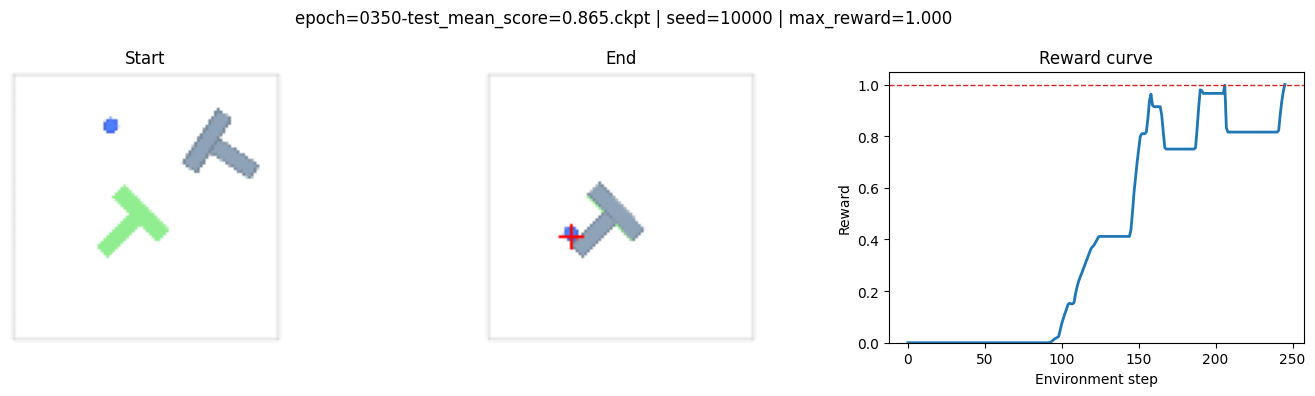

In [2]:
checkpoint_path = default_checkpoint()
seed = 10000
result = run_rollout(checkpoint_path=checkpoint_path, seed=seed, device=device)
print({
    'checkpoint': result['checkpoint_name'],
    'seed': result['seed'],
    'device': result['device'],
    'env_steps': result['n_env_steps'],
    'decision_steps': result['n_decisions'],
    'max_reward': round(result['max_reward'], 4),
    'success': result['success'],
})
fig = plot_rollout(result)
plt.show()

In [3]:
gif_path = save_gif(result, fps=5)
gif_path

WindowsPath('C:/Users/moise/Documents/0001_MADI/TFM/diffuser/artifacts/v0_inference/gifs/epoch_0350-test_mean_score_0.865_seed10000.gif')

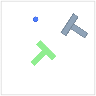

In [4]:
display(Image(filename=str(gif_path)))

c:\Users\moise\Documents\0001_MADI\TFM\.venv_diffuser_infer\Lib\site-packages\shapely\set_operations.py:131: RuntimeWarning: divide by zero encountered in intersection
  return lib.intersection(a, b, **kwargs)


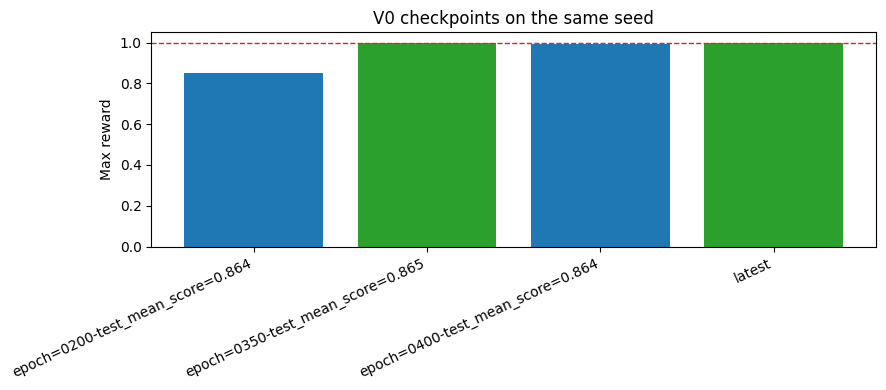

In [5]:
comparison = compare_checkpoints(seed=seed, device=device)
comparison
fig = plot_checkpoint_comparison(comparison)
plt.show()